<a href="https://colab.research.google.com/github/vincent-chen09/MG-Gravitational-waves/blob/main/GW150914_Parameter_Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install gwpy
%pip install lalsuite
%pip install bilby

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.6/128.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 43.9 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 45.0.6 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 45.0.6 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bilby
from bilby.core.prior import Uniform
from gwpy.timeseries import TimeSeries
logger = bilby.core.utils.logger
outdir = "/content/drive/My Drive/Results/"


label = "GW150914"

H1 = bilby.gw.detector.get_empty_interferometer("H1")
L1 = bilby.gw.detector.get_empty_interferometer("L1")

/usr/local/lib/python3.11/dist-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


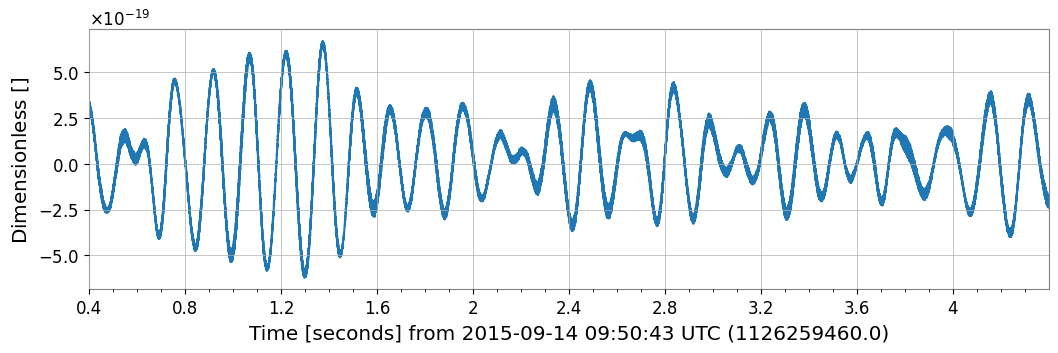

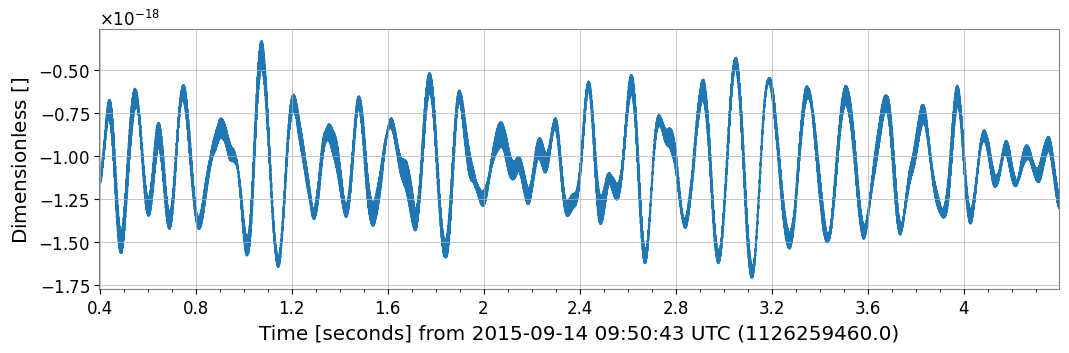

In [ ]:
event_start_time = 1126259462.4    # event GPS time at which first GW discovered
post_event = 2                     # time after event
pre_event = 2                      # time before event
duration = pre_event + post_event  # total time range containing event
analysis_begin = event_start_time - pre_event
H1_data = TimeSeries.fetch_open_data("H1", analysis_begin,
                                     analysis_begin + duration,
                                     sample_rate=4096, cache=True)

L1_data = TimeSeries.fetch_open_data("L1", analysis_begin,
                                     analysis_begin + duration,
                                     sample_rate=4096, cache=True)

H1_data.plot()
plt.savefig("H1_data")
L1_data.plot()
plt.savefig("L1_data")

In [ ]:
H1.set_strain_data_from_gwpy_timeseries(H1_data)
L1.set_strain_data_from_gwpy_timeseries(L1_data)

In [ ]:
# duration typically multiplied by 32 for psd
psd_duration = duration * 32
psd_begin = analysis_begin - psd_duration

# fetch data for psd
H1psd = TimeSeries.fetch_open_data(
    "H1", psd_begin, psd_begin + psd_duration,
    sample_rate=4096, cache=True)
L1psd = TimeSeries.fetch_open_data(
    "L1", psd_begin, psd_begin + psd_duration,
    sample_rate=4096, cache=True)

# set interferometers with psd data
psd_alpha = 2 * H1.strain_data.roll_off / duration
H1psd_data = H1psd.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
L1psd_data = L1psd.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
H1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=H1psd_data.frequencies.value, psd_array=H1psd_data.value)
L1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=L1psd_data.frequencies.value, psd_array=L1psd_data.value)

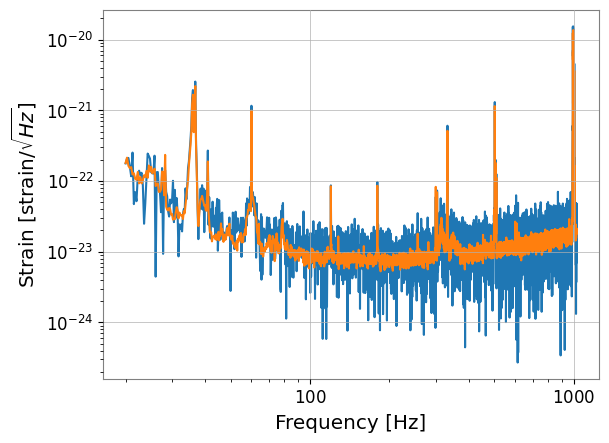

In [ ]:
H1.maximum_frequency = 1024
L1.maximum_frequency = 1024

plt.figure()
idxs = H1.strain_data.frequency_mask
a,b = list(H1.strain_data.frequency_array[idxs]),list(np.abs(H1.strain_data.frequency_domain_strain[idxs]))
c,d = list(H1.power_spectral_density.frequency_array[idxs]),list(H1.power_spectral_density.asd_array[idxs])
plt.plot(a,b)
plt.plot(c,d)
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Frequency [Hz]")
plt.ylabel("Strain [strain/$\sqrt{Hz}$]")
plt.savefig("strainvfreq")


In [ ]:
prior = bilby.core.prior.PriorDict()
# uniform priors for variable parameters
prior['chirp_mass'] = Uniform(name='chirp_mass', minimum=10.0,maximum=100.0)
prior['mass_ratio'] = Uniform(name='mass_ratio', minimum=0.5, maximum=1)
prior['phase'] = Uniform(name="phase", minimum=0, maximum=2*np.pi)
#prior['geocent_time'] = Uniform(name="geocent_time", minimum=event_start_time-0.1,
                                #maximum=event_start_time+0.1)
prior['luminosity_distance'] = Uniform(name="luminosity_distance", minimum =200, maximum = 600)
# fixed values for all other parameters
prior['a_1'] =  0.0
prior['a_2'] =  0.0
prior['tilt_1'] =  0.0
prior['tilt_2'] =  0.0
prior['phi_12'] =  0.0
prior['phi_jl'] =  0.0
prior['dec'] =  -1.2232 #declination
prior['ra'] =  2.19432  #right ascension
prior['theta_jn'] =  1.89694 #angles between line of sight and plane
prior['psi'] =  0.532268 #polarization angle of wave
prior['geocent_time'] = 1126259462.41

interferometers = [H1, L1]

waveform_arguments = dict(waveform_approximant='IMRPhenomPv2',
                          reference_frequency=50., minimum_frequency=20.)

# set sampling frequency of data
sampling_frequency = 2048.

# generate waveforms
waveform_generator = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments)

likelihood = bilby.gw.GravitationalWaveTransient(
    interferometers=interferometers, waveform_generator=waveform_generator)

NameError: name 'bilby' is not defined

In [ ]:
nlive = 1000          # live points
stop = 0.1            # stopping criterion(change in log of posterior probability)
method = "unif"       # method of sampling
sampler = "dynesty"   # sampler to use

result = bilby.run_sampler(
    likelihood, prior, sampler=sampler, outdir=outdir, label=label,
    conversion_function=bilby.gw.conversion.generate_all_bbh_parameters,
    sample=method, nlive=nlive, dlogz=stop)

result.plot_corner()

23:10 bilby INFO    : Running for label 'GW150914', output will be saved to '/content/drive/My Drive/Results/'
23:10 bilby INFO    : Using lal version 7.7.0
23:10 bilby INFO    : Using lal git version Branch: None;Tag: lalsuite-v7.26.1;Id: c90e1175f5e238741185744a4e516e58d42a9aec;;Builder: Unknown User <>;Repository status: CLEAN: All modifications committed
23:10 bilby INFO    : Using lalsimulation version 6.2.0
23:10 bilby INFO    : Using lalsimulation git version Branch: None;Tag: lalsuite-v7.26.1;Id: c90e1175f5e238741185744a4e516e58d42a9aec;;Builder: Unknown User <>;Repository status: CLEAN: All modifications committed
23:10 bilby INFO    : Analysis priors:
23:10 bilby INFO    : chirp_mass=Uniform(minimum=10.0, maximum=100.0, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, boundary=None)
23:10 bilby INFO    : mass_ratio=Uniform(minimum=0.5, maximum=1, name='mass_ratio', latex_label='$q$', unit=None, boundary=None)
23:10 bilby INFO    : phase=Uniform(minimum=0, maximum=6

18721it [00:00, ?it/s]

23:10 bilby INFO    : Written checkpoint file /content/drive/My Drive/Results//GW150914_resume.pickle
23:11 bilby INFO    : Rejection sampling nested samples to obtain 3680 posterior samples
23:11 bilby INFO    : Sampling time: 7:06:37.956867


23:11 bilby INFO    : Computing per-detector log likelihoods.


  0%|          | 0/3680 [00:00<?, ?it/s]

23:16 bilby INFO    : Computing SNRs for every sample.


  0%|          | 0/3680 [00:00<?, ?it/s]

CosmologyError: Best guess z=999.9999865617187 is very close to the upper z limit 1000.0.
Try re-running with a different zmax.

In [ ]:
posts = result.posterior
#posts = pd.read_csv("/content/drive/My Drive/Results/GW150914_result.json", sep = " ")

